In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
# Load saved data from Task 1
data_path = Path('../data/processed/')

# If you didn't save in Task 1, load from raw
if not data_path.exists():
    data_path = Path('../data/raw/')

# Load stock data for all tickers
tickers = ['AAPL', 'GOOG', 'AMZN', 'META', 'NVDA']
stock_data = {}

for ticker in tickers:
    file_path = data_path / f"{ticker}.csv"
    if not file_path.exists():
        file_path = Path('../data/raw/') / f"{ticker}.csv"
    
    if file_path.exists():
        df = pd.read_csv(file_path)
        # Convert date column
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'])
            df.set_index('Date', inplace=True)
        stock_data[ticker] = df
        print(f"✅ Loaded {ticker}: {len(df)} rows")
    else:
        print(f"❌ Could not find {ticker}.csv")

print(f"\n📈 Loaded {len(stock_data)} stocks")

✅ Loaded AAPL: 3774 rows
✅ Loaded GOOG: 3774 rows
✅ Loaded AMZN: 3774 rows
✅ Loaded META: 2923 rows
✅ Loaded NVDA: 3774 rows

📈 Loaded 5 stocks


In [3]:
# Install TA-Lib (run this once)
import subprocess
import sys

try:
    import talib
    print("✅ TA-Lib already installed")
except:
    print("📦 Installing TA-Lib...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "TA-Lib"])
    import talib
    print("✅ TA-Lib installed successfully!")

# Import other libraries
import talib as ta

✅ TA-Lib already installed


In [4]:
def calculate_technical_indicators(df, ticker):
    """Calculate all technical indicators for a stock"""
    
    df = df.copy()
    
    # Make sure we have the correct column names
    close_col = 'Close' if 'Close' in df.columns else 'close' if 'close' in df.columns else None
    high_col = 'High' if 'High' in df.columns else 'high' if 'high' in df.columns else None
    low_col = 'Low' if 'Low' in df.columns else 'low' if 'low' in df.columns else None
    volume_col = 'Volume' if 'Volume' in df.columns else 'volume' if 'volume' in df.columns else None
    
    if close_col is None:
        print(f"❌ No Close column found for {ticker}")
        return df
    
    close_prices = df[close_col].values
    high_prices = df[high_col].values if high_col else close_prices
    low_prices = df[low_col].values if low_col else close_prices
    volume = df[volume_col].values if volume_col else None
    
    # 1. Moving Averages
    df['SMA_10'] = ta.SMA(close_prices, timeperiod=10)
    df['SMA_20'] = ta.SMA(close_prices, timeperiod=20)
    df['SMA_50'] = ta.SMA(close_prices, timeperiod=50)
    df['EMA_10'] = ta.EMA(close_prices, timeperiod=10)
    df['EMA_20'] = ta.EMA(close_prices, timeperiod=20)
    
    # 2. RSI (Relative Strength Index)
    df['RSI_14'] = ta.RSI(close_prices, timeperiod=14)
    
    # 3. MACD
    df['MACD'], df['MACD_signal'], df['MACD_hist'] = ta.MACD(close_prices, fastperiod=12, slowperiod=26, signalperiod=9)
    
    # 4. Bollinger Bands
    df['BB_upper'], df['BB_middle'], df['BB_lower'] = ta.BBANDS(close_prices, timeperiod=20, nbdevup=2, nbdevdn=2)
    
    # 5. ATR (Average True Range - Volatility)
    df['ATR_14'] = ta.ATR(high_prices, low_prices, close_prices, timeperiod=14)
    
    # 6. Volume indicators
    if volume is not None:
        df['OBV'] = ta.OBV(close_prices, volume)  # On-Balance Volume
        df['Volume_SMA'] = ta.SMA(volume, timeperiod=20)
    
    # 7. Support and Resistance (using rolling windows)
    df['Resistance'] = df[close_col].rolling(window=20).max()
    df['Support'] = df[close_col].rolling(window=20).min()
    
    print(f"✅ Calculated indicators for {ticker}")
    return df

In [6]:
def calculate_technical_indicators(df, ticker):
    """Calculate all technical indicators for a stock"""
    
    df = df.copy()
    
    # Make sure we have the correct column names
    close_col = 'Close' if 'Close' in df.columns else 'close' if 'close' in df.columns else None
    high_col = 'High' if 'High' in df.columns else 'high' if 'high' in df.columns else None
    low_col = 'Low' if 'Low' in df.columns else 'low' if 'low' in df.columns else None
    volume_col = 'Volume' if 'Volume' in df.columns else 'volume' if 'volume' in df.columns else None
    
    if close_col is None:
        print(f"❌ No Close column found for {ticker}")
        return df
    
    # Convert to float64 (double) as required by TA-Lib
    close_prices = df[close_col].values.astype(np.float64)
    
    if high_col:
        high_prices = df[high_col].values.astype(np.float64)
    else:
        high_prices = close_prices
        
    if low_col:
        low_prices = df[low_col].values.astype(np.float64)
    else:
        low_prices = close_prices
        
    if volume_col:
        volume = df[volume_col].values.astype(np.float64)
    else:
        volume = None
    
    # 1. Moving Averages
    df['SMA_10'] = ta.SMA(close_prices, timeperiod=10)
    df['SMA_20'] = ta.SMA(close_prices, timeperiod=20)
    df['SMA_50'] = ta.SMA(close_prices, timeperiod=50)
    df['EMA_10'] = ta.EMA(close_prices, timeperiod=10)
    df['EMA_20'] = ta.EMA(close_prices, timeperiod=20)
    
    # 2. RSI (Relative Strength Index)
    df['RSI_14'] = ta.RSI(close_prices, timeperiod=14)
    
    # 3. MACD
    df['MACD'], df['MACD_signal'], df['MACD_hist'] = ta.MACD(close_prices, fastperiod=12, slowperiod=26, signalperiod=9)
    
    # 4. Bollinger Bands
    df['BB_upper'], df['BB_middle'], df['BB_lower'] = ta.BBANDS(close_prices, timeperiod=20, nbdevup=2, nbdevdn=2)
    
    # 5. ATR (Average True Range - Volatility)
    df['ATR_14'] = ta.ATR(high_prices, low_prices, close_prices, timeperiod=14)
    
    # 6. Volume indicators (only if volume data exists)
    if volume is not None:
        try:
            df['OBV'] = ta.OBV(close_prices, volume)  # On-Balance Volume
            df['Volume_SMA'] = ta.SMA(volume, timeperiod=20)
        except:
            print(f"  ⚠️ Could not calculate volume indicators for {ticker}")
            df['OBV'] = np.nan
            df['Volume_SMA'] = np.nan
    
    # 7. Support and Resistance (using rolling windows)
    df['Resistance'] = df[close_col].rolling(window=20).max()
    df['Support'] = df[close_col].rolling(window=20).min()
    
    print(f"✅ Calculated indicators for {ticker}")
    return df

In [7]:
# Calculate indicators for each stock
for ticker in stock_data.keys():
    stock_data[ticker] = calculate_technical_indicators(stock_data[ticker], ticker)

print("\n🎉 All technical indicators calculated!")

✅ Calculated indicators for AAPL
✅ Calculated indicators for GOOG
✅ Calculated indicators for AMZN
✅ Calculated indicators for META
✅ Calculated indicators for NVDA

🎉 All technical indicators calculated!


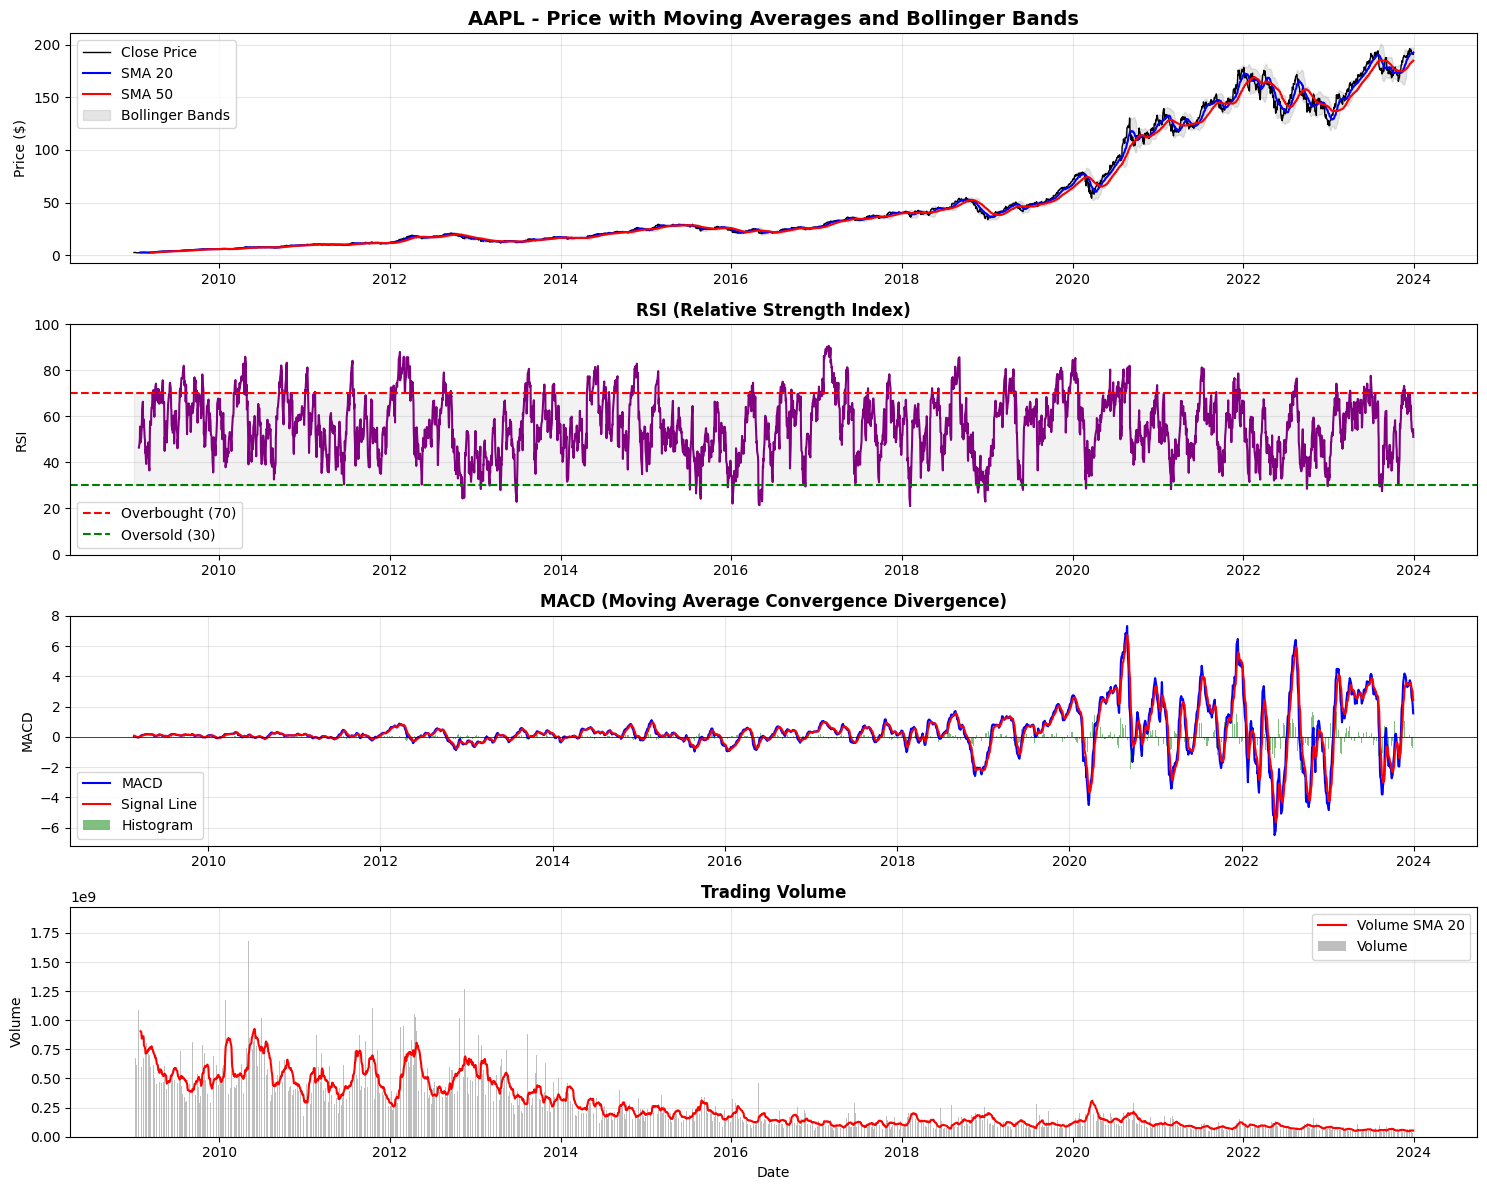

In [8]:
# Pick a stock to visualize
ticker_to_plot = 'AAPL'
df = stock_data[ticker_to_plot]

# Create figure with subplots
fig = plt.figure(figsize=(15, 12))

# 1. Price and Moving Averages
ax1 = plt.subplot(4, 1, 1)
ax1.plot(df.index, df['Close'], label='Close Price', linewidth=1, color='black')
ax1.plot(df.index, df['SMA_20'], label='SMA 20', linewidth=1.5, color='blue')
ax1.plot(df.index, df['SMA_50'], label='SMA 50', linewidth=1.5, color='red')
ax1.fill_between(df.index, df['BB_lower'], df['BB_upper'], alpha=0.2, color='gray', label='Bollinger Bands')
ax1.set_title(f'{ticker_to_plot} - Price with Moving Averages and Bollinger Bands', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. RSI
ax2 = plt.subplot(4, 1, 2)
ax2.plot(df.index, df['RSI_14'], linewidth=1.5, color='purple')
ax2.axhline(y=70, color='r', linestyle='--', label='Overbought (70)')
ax2.axhline(y=30, color='g', linestyle='--', label='Oversold (30)')
ax2.fill_between(df.index, 30, 70, alpha=0.1, color='gray')
ax2.set_title('RSI (Relative Strength Index)', fontsize=12, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. MACD
ax3 = plt.subplot(4, 1, 3)
ax3.plot(df.index, df['MACD'], label='MACD', linewidth=1.5, color='blue')
ax3.plot(df.index, df['MACD_signal'], label='Signal Line', linewidth=1.5, color='red')
ax3.bar(df.index, df['MACD_hist'], label='Histogram', alpha=0.5, color='green', width=0.8)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_title('MACD (Moving Average Convergence Divergence)', fontsize=12, fontweight='bold')
ax3.set_ylabel('MACD')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Volume
ax4 = plt.subplot(4, 1, 4)
ax4.bar(df.index, df['Volume'], alpha=0.5, color='gray', label='Volume')
if 'Volume_SMA' in df.columns:
    ax4.plot(df.index, df['Volume_SMA'], linewidth=1.5, color='red', label='Volume SMA 20')
ax4.set_title('Trading Volume', fontsize=12, fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Volume')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

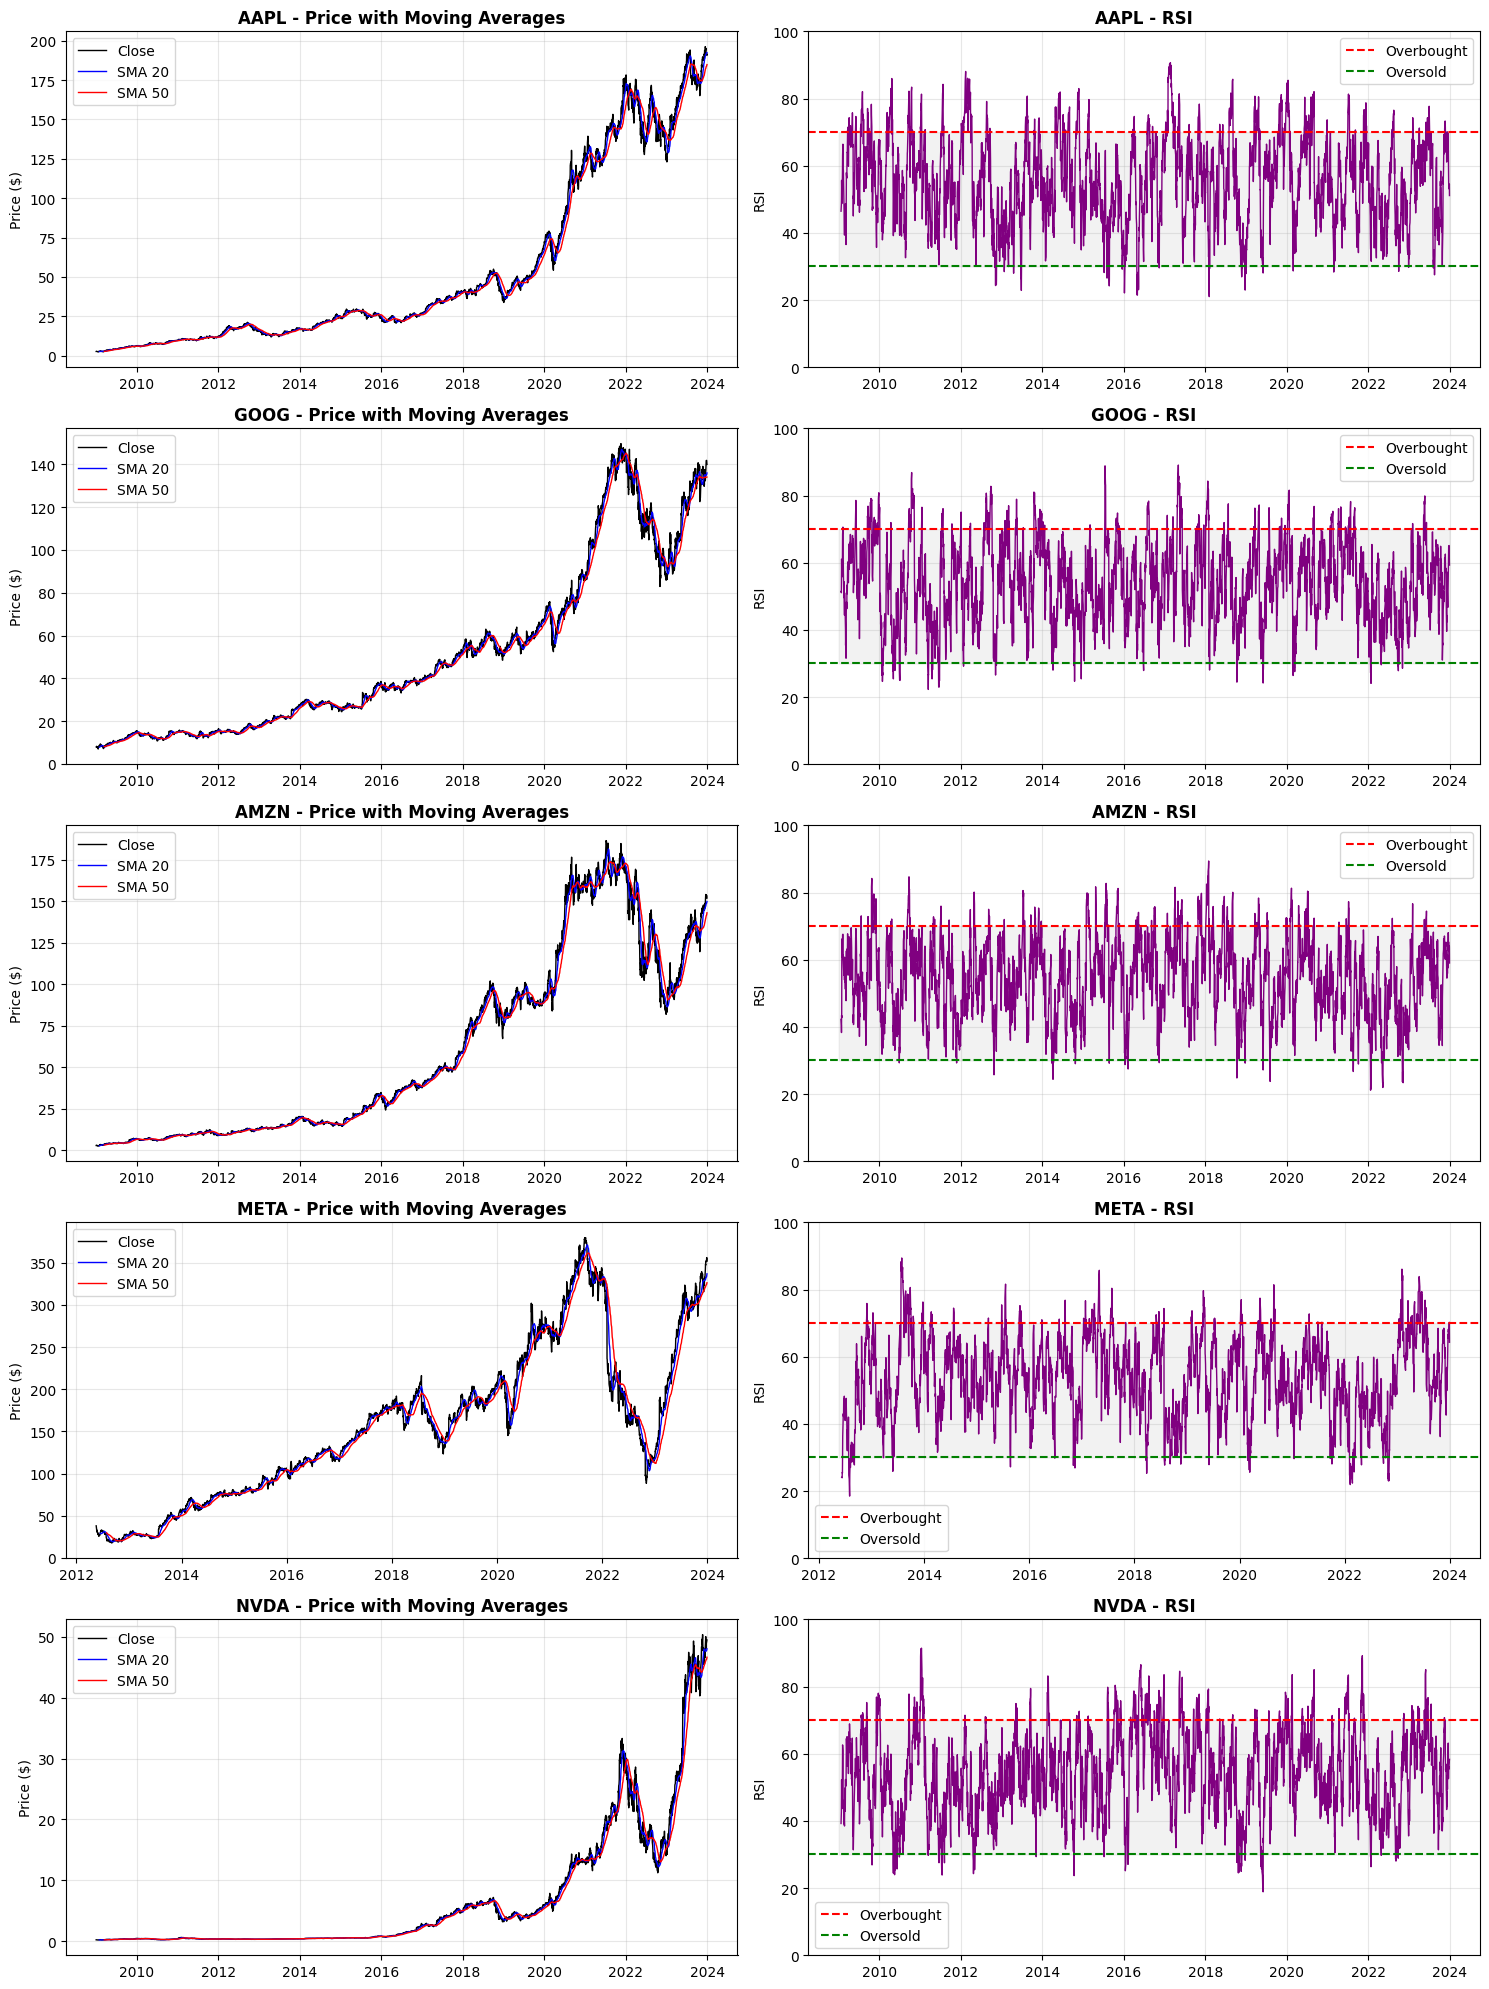

In [9]:
# Create subplots for all stocks
fig, axes = plt.subplots(len(stock_data), 2, figsize=(15, 4*len(stock_data)))

if len(stock_data) == 1:
    axes = axes.reshape(1, -1)

for idx, (ticker, df) in enumerate(stock_data.items()):
    # Price with SMA
    axes[idx, 0].plot(df.index, df['Close'], label='Close', linewidth=1, color='black')
    axes[idx, 0].plot(df.index, df['SMA_20'], label='SMA 20', linewidth=1, color='blue')
    axes[idx, 0].plot(df.index, df['SMA_50'], label='SMA 50', linewidth=1, color='red')
    axes[idx, 0].set_title(f'{ticker} - Price with Moving Averages', fontsize=12, fontweight='bold')
    axes[idx, 0].set_ylabel('Price ($)')
    axes[idx, 0].legend(loc='upper left')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # RSI
    axes[idx, 1].plot(df.index, df['RSI_14'], linewidth=1, color='purple')
    axes[idx, 1].axhline(y=70, color='r', linestyle='--', label='Overbought')
    axes[idx, 1].axhline(y=30, color='g', linestyle='--', label='Oversold')
    axes[idx, 1].fill_between(df.index, 30, 70, alpha=0.1, color='gray')
    axes[idx, 1].set_title(f'{ticker} - RSI', fontsize=12, fontweight='bold')
    axes[idx, 1].set_ylabel('RSI')
    axes[idx, 1].set_ylim(0, 100)
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
def get_trading_signals(df, ticker):
    """Identify buy/sell signals based on technical indicators"""
    
    signals = pd.DataFrame(index=df.index)
    
    # RSI signals
    signals['RSI_Oversold'] = df['RSI_14'] < 30
    signals['RSI_Overbought'] = df['RSI_14'] > 70
    
    # MACD signals
    signals['MACD_Bullish'] = (df['MACD'] > df['MACD_signal']) & (df['MACD'].shift(1) <= df['MACD_signal'].shift(1))
    signals['MACD_Bearish'] = (df['MACD'] < df['MACD_signal']) & (df['MACD'].shift(1) >= df['MACD_signal'].shift(1))
    
    # Price vs MA signals
    signals['Price_Above_SMA20'] = df['Close'] > df['SMA_20']
    signals['Price_Below_SMA20'] = df['Close'] < df['SMA_20']
    
    # Golden Cross (50 SMA crosses above 200 SMA) - using 20 and 50 for shorter timeframe
    signals['Golden_Cross'] = (df['SMA_20'] > df['SMA_50']) & (df['SMA_20'].shift(1) <= df['SMA_50'].shift(1))
    signals['Death_Cross'] = (df['SMA_20'] < df['SMA_50']) & (df['SMA_20'].shift(1) >= df['SMA_50'].shift(1))
    
    # Combine signals
    signals['Buy_Signal'] = signals['RSI_Oversold'] | signals['MACD_Bullish'] | signals['Golden_Cross']
    signals['Sell_Signal'] = signals['RSI_Overbought'] | signals['MACD_Bearish'] | signals['Death_Cross']
    
    return signals

# Get signals for all stocks
all_signals = {}
for ticker, df in stock_data.items():
    all_signals[ticker] = get_trading_signals(df, ticker)
    
    print(f"\n{'='*50}")
    print(f"{ticker} - Trading Signals Summary")
    print(f"{'='*50}")
    print(f"Buy Signals: {all_signals[ticker]['Buy_Signal'].sum()} days")
    print(f"Sell Signals: {all_signals[ticker]['Sell_Signal'].sum()} days")
    print(f"Last Buy Signal: {all_signals[ticker][all_signals[ticker]['Buy_Signal']].index[-1].date() if all_signals[ticker]['Buy_Signal'].any() else 'None'}")
    print(f"Last Sell Signal: {all_signals[ticker][all_signals[ticker]['Sell_Signal']].index[-1].date() if all_signals[ticker]['Sell_Signal'].any() else 'None'}")


AAPL - Trading Signals Summary
Buy Signals: 250 days
Sell Signals: 746 days
Last Buy Signal: 2023-12-13
Last Sell Signal: 2023-12-19

GOOG - Trading Signals Summary
Buy Signals: 257 days
Sell Signals: 573 days
Last Buy Signal: 2023-12-19
Last Sell Signal: 2023-12-01

AMZN - Trading Signals Summary
Buy Signals: 236 days
Sell Signals: 527 days
Last Buy Signal: 2023-12-18
Last Sell Signal: 2023-12-29

META - Trading Signals Summary
Buy Signals: 225 days
Sell Signals: 381 days
Last Buy Signal: 2023-12-15
Last Sell Signal: 2023-12-28

NVDA - Trading Signals Summary
Buy Signals: 265 days
Sell Signals: 632 days
Last Buy Signal: 2023-12-15
Last Sell Signal: 2023-11-28


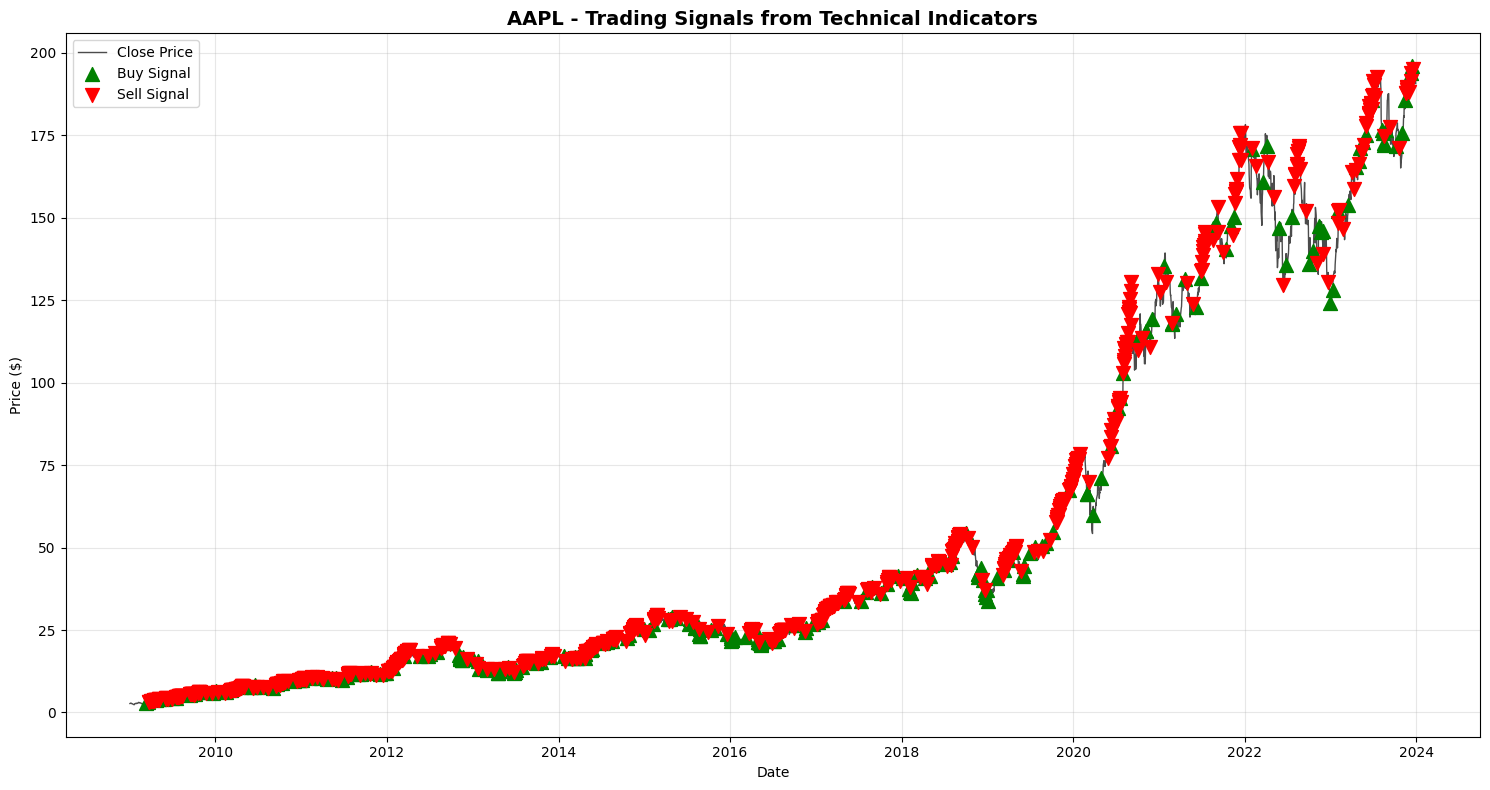

In [11]:
# Plot buy/sell signals for AAPL
ticker = 'AAPL'
df_signals = all_signals[ticker]
df_price = stock_data[ticker]

fig, ax = plt.subplots(figsize=(15, 8))

# Plot price
ax.plot(df_price.index, df_price['Close'], label='Close Price', linewidth=1, color='black', alpha=0.7)

# Plot buy signals
buy_dates = df_signals[df_signals['Buy_Signal']].index
buy_prices = df_price.loc[buy_dates, 'Close']
ax.scatter(buy_dates, buy_prices, color='green', marker='^', s=100, label='Buy Signal', zorder=5)

# Plot sell signals
sell_dates = df_signals[df_signals['Sell_Signal']].index
sell_prices = df_price.loc[sell_dates, 'Close']
ax.scatter(sell_dates, sell_prices, color='red', marker='v', s=100, label='Sell Signal', zorder=5)

ax.set_title(f'{ticker} - Trading Signals from Technical Indicators', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
print("=" * 80)
print("TECHNICAL INDICATORS SUMMARY")
print("=" * 80)

for ticker, df in stock_data.items():
    print(f"\n📊 {ticker}")
    print("-" * 40)
    
    # Latest values
    latest = df.iloc[-1]
    print(f"Latest Close Price: ${latest['Close']:.2f}")
    print(f"Latest RSI (14): {latest['RSI_14']:.2f}")
    
    # RSI condition
    if latest['RSI_14'] > 70:
        print(f"  ⚠️  OVERBOUGHT condition (RSI > 70)")
    elif latest['RSI_14'] < 30:
        print(f"  ✅ OVERSOLD condition (RSI < 30)")
    else:
        print(f"  ➡️  Neutral RSI")
    
    # MACD condition
    if latest['MACD'] > latest['MACD_signal']:
        print(f"  📈 MACD BULLISH (above signal line)")
    else:
        print(f"  📉 MACD BEARISH (below signal line)")
    
    # Price vs MA
    if latest['Close'] > latest['SMA_20']:
        print(f"  📈 Price above SMA 20 (uptrend)")
    else:
        print(f"  📉 Price below SMA 20 (downtrend)")
    
    # Volatility (ATR)
    print(f"  📊 Volatility (ATR): ${latest['ATR_14']:.2f}")

print("\n" + "=" * 80)
print("✅ TASK 2 COMPLETE!")
print("📌 Ready to proceed to Task 3: Correlation Analysis")
print("=" * 80)

TECHNICAL INDICATORS SUMMARY

📊 AAPL
----------------------------------------
Latest Close Price: $190.73
Latest RSI (14): 51.12
  ➡️  Neutral RSI
  📉 MACD BEARISH (below signal line)
  📉 Price below SMA 20 (downtrend)
  📊 Volatility (ATR): $2.55

📊 GOOG
----------------------------------------
Latest Close Price: $139.97
Latest RSI (14): 59.31
  ➡️  Neutral RSI
  📈 MACD BULLISH (above signal line)
  📈 Price above SMA 20 (uptrend)
  📊 Volatility (ATR): $2.64

📊 AMZN
----------------------------------------
Latest Close Price: $151.94
Latest RSI (14): 59.01
  ➡️  Neutral RSI
  📉 MACD BEARISH (below signal line)
  📈 Price above SMA 20 (uptrend)
  📊 Volatility (ATR): $2.81

📊 META
----------------------------------------
Latest Close Price: $351.79
Latest RSI (14): 64.30
  ➡️  Neutral RSI
  📈 MACD BULLISH (above signal line)
  📈 Price above SMA 20 (uptrend)
  📊 Volatility (ATR): $7.30

📊 NVDA
----------------------------------------
Latest Close Price: $49.50
Latest RSI (14): 58.31
  ➡️  

In [13]:
# Save processed data with indicators
processed_path = Path('../data/processed/')
processed_path.mkdir(parents=True, exist_ok=True)

for ticker, df in stock_data.items():
    df.to_csv(processed_path / f'{ticker}_with_indicators.csv')
    print(f"✅ Saved {ticker} with indicators")

print("\n🎉 All data saved! Ready for Task 3!")

✅ Saved AAPL with indicators
✅ Saved GOOG with indicators
✅ Saved AMZN with indicators
✅ Saved META with indicators
✅ Saved NVDA with indicators

🎉 All data saved! Ready for Task 3!


In [14]:
# Cell E: Technical Indicators
print("\n=== TECHNICAL INDICATORS (Latest Values) ===")
for ticker, df in stock_data.items():
    latest = df.iloc[-1]
    print(f"\n{ticker}:")
    print(f"  Current Price: ${latest['Close']:.2f}")
    print(f"  RSI (14): {latest['RSI_14']:.1f}")
    
    # Determine signal
    if latest['RSI_14'] > 70:
        signal = "OVERBOUGHT (Sell Signal)"
    elif latest['RSI_14'] < 30:
        signal = "OVERSOLD (Buy Signal)"
    else:
        signal = "Neutral"
    print(f"  Signal: {signal}")


=== TECHNICAL INDICATORS (Latest Values) ===

AAPL:
  Current Price: $190.73
  RSI (14): 51.1
  Signal: Neutral

GOOG:
  Current Price: $139.97
  RSI (14): 59.3
  Signal: Neutral

AMZN:
  Current Price: $151.94
  RSI (14): 59.0
  Signal: Neutral

META:
  Current Price: $351.79
  RSI (14): 64.3
  Signal: Neutral

NVDA:
  Current Price: $49.50
  RSI (14): 58.3
  Signal: Neutral
